# Elaad - Data processing
*By: Dario Slaifstein, PhD Candidate*
*   Alvar, PhD Candidate*
<br> Group: DCES
<br> Project: **FLEXINet**
<br> Result: 6

Source control
- Branch: `evDrivingModeling`
- version: `1.1`
- Date: 03/04/2023

In [1]:
using StatsBase, StatsPlots, LinearAlgebra, IterTools, Distributions, CSV, DataFrames, LaTeXStrings
# using Makie, CairoMakie

# 1. Arrival times

This notebook process the data from [Elaad](https://platform.elaad.io/analyses/ElaadNL_opendata.php) and creates the distributions for the EVs of the FLEXINet project.
The output of the notebook is the parameters of the distrbutions of $t_{dep/arr}$

In [2]:
## Load Input Data
# Load the data from the EV Profile Tool
# density function of the arrival times
arr_times_df = CSV.read("input/Elaad Data/Data downloaded/distribution-of-arrival-weekdays.csv", DataFrame);
arr_times_df

Row,Arrival time,private,public,workplace
,Time,Float64,Float64,Float64
1,00:00:00,0.87,0.35,0.01
2,00:15:00,0.59,0.25,0.01
3,00:30:00,0.4,0.22,0.01
4,00:45:00,0.27,0.16,0.01
5,01:00:00,0.2,0.14,0.0
6,01:15:00,0.15,0.13,0.0
7,01:30:00,0.11,0.1,0.0
8,01:45:00,0.07,0.08,0.0
9,02:00:00,0.08,0.07,0.0


In [3]:
μD_tarr_df = CSV.read("input/Elaad Data/Data downloaded/mean-session-length-per.csv", DataFrame);
# change missing values to 0
replace!(μD_tarr_df.work, missing => 0)
# sort following the arrival times
sort!(μD_tarr_df, "Arrival Time")
μD_tarr_df

┌ Warning: thread = 1 warning: only found 3 / 4 columns around data row: 1. Filling remaining columns with `missing`
└ @ CSV C:\Users\dslaifstein\.julia\packages\CSV\aoJqo\src\file.jl:586
┌ Warning: thread = 1 warning: only found 3 / 4 columns around data row: 3. Filling remaining columns with `missing`
└ @ CSV C:\Users\dslaifstein\.julia\packages\CSV\aoJqo\src\file.jl:586
┌ Warning: thread = 1 warning: only found 3 / 4 columns around data row: 5. Filling remaining columns with `missing`
└ @ CSV C:\Users\dslaifstein\.julia\packages\CSV\aoJqo\src\file.jl:586
┌ Warning: thread = 1 warning: only found 3 / 4 columns around data row: 7. Filling remaining columns with `missing`
└ @ CSV C:\Users\dslaifstein\.julia\packages\CSV\aoJqo\src\file.jl:586
┌ Warning: thread = 1 warning: only found 3 / 4 columns around data row: 9. Filling remaining columns with `missing`
└ @ CSV C:\Users\dslaifstein\.julia\packages\CSV\aoJqo\src\file.jl:586
┌ Warning: thread = 1 warning: only found 3 / 4 columns arou

Row,Arrival Time,home,public,work
,Time,Float64,Float64,Float64?
1,00:00:00,9.3,10.0,0.0
2,00:30:00,8.9,10.0,0.0
3,01:00:00,9.2,10.0,0.0
4,01:30:00,8.6,9.8,0.0
5,02:00:00,7.9,9.7,0.0
6,02:30:00,6.5,9.3,0.0
7,03:00:00,5.7,8.9,0.0
8,03:30:00,5.65,8.0,0.0
9,04:00:00,4.8,7.3,0.0


In [4]:
# Normalize the arrival times to 1
for i in 2:size(arr_times_df, 2)
    arr_times_df[:, i] = arr_times_df[:, i]/sum(arr_times_df[:, i])
end
# add extra column with arrival times in secs Float64
arr_times_df[!, :arrival_times] = (0:0.25:23.75)*3600.0;

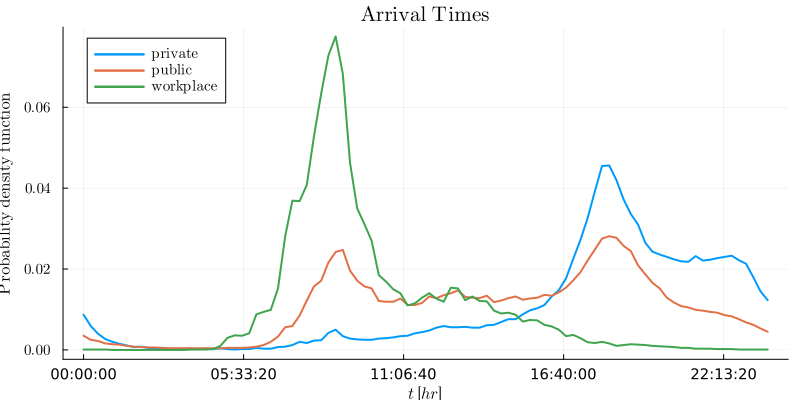

In [5]:
using Plots
plot!(arr_times_df[:, 1], arr_times_df[:, 2], label=L"\textrm{private}", linewidth=2, 
        xlabel=L"t\ [hr]", ylabel=L"\textrm{Probability\ density\ function}",
        legend=:topleft, title=L"\textrm{Arrival\ Times}", size=(800, 400))
plot!(arr_times_df[:, 1], arr_times_df[:, 3], label=L"\textrm{public}", linewidth=2)
plot!(arr_times_df[:, 1], arr_times_df[:, 4], label=L"\textrm{workplace}", linewidth=2,
        xformatter=:latex, yformatter=:latex, xtickfontsize=10, ytickfontsize=10, legendfontsize=10)

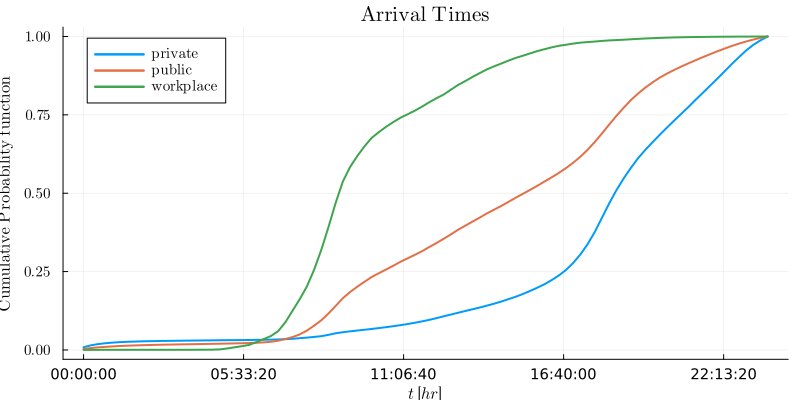

In [5]:
plot(arr_times_df[:, 1], cumsum(arr_times_df[:, 2]), label=L"\textrm{private}", linewidth=2, 
        xlabel=L"t\ [hr]", ylabel=L"\textrm{Cumulative\ Probability\ function}",
        legend=:topleft, title=L"\textrm{Arrival\ Times}", size=(800, 400))
plot!(arr_times_df[:, 1], cumsum(arr_times_df[:, 3]), label=L"\textrm{public}", linewidth=2)
plot!(arr_times_df[:, 1], cumsum(arr_times_df[:, 4]), label=L"\textrm{workplace}", linewidth=2,
        xformatter=:latex, yformatter=:latex, xtickfontsize=10, ytickfontsize=10, legendfontsize=10)

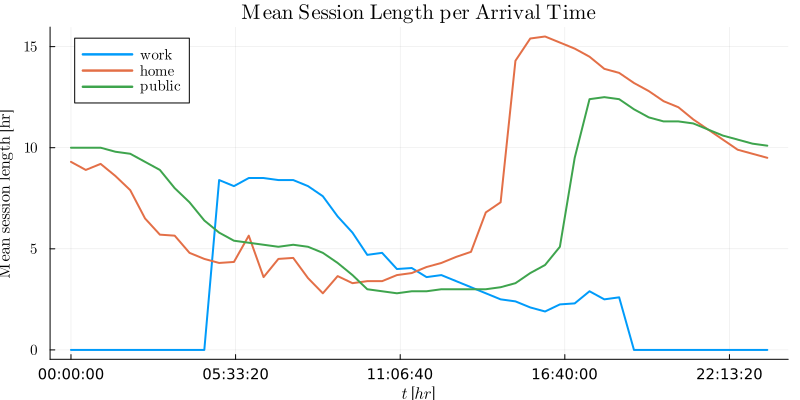

In [16]:
# plot the mean session length per arrival time using Plots.jl
plot(μD_tarr_df[!, "Arrival Time"], μD_tarr_df[!, :work], label=L"\textrm{work}", linewidth=2, 
        xlabel=L"t\ [hr]", ylabel=L"\textrm{Mean\ session\ length\ [hr]}",
        legend=:topleft, title=L"\textrm{Mean\ Session\ Length\ per\ Arrival\ Time}", size=(800, 400))
plot!(μD_tarr_df[!, "Arrival Time"], μD_tarr_df[!, :home], label=L"\textrm{home}", linewidth=2)
plot!(μD_tarr_df[!, "Arrival Time"], μD_tarr_df[!, :public], label=L"\textrm{public}", linewidth=2,
        xformatter=:latex, yformatter=:latex, xtickfontsize=10, ytickfontsize=10, legendfontsize=10)

# # plot the mean session length per arrival time
# plot(μD_tarr_df[!, "Arrival Time"], cumsum(μD_tarr_df[!, :work])/maximum(cumsum(μD_tarr_df[!, :work])), label=L"\textrm{work}", linewidth=2, 
#         xlabel=L"t\ [hr]", ylabel=L"\textrm{Cumulative\ mean\ session\ length\ [s]}",)

In [17]:
using GaussianMixtures

The idea now is to create a bimodal distribution $f()$ for each sector ("private", "public" and "workplace"). The model is then a linear combination of different unimodal distributions $f_k$:

\begin{equation}
    f(x,\Theta, \pi)=\sum_{k=1}^{K} \pi_k . f_k(x, \theta_k)
\end{equation}

We will use 2 mixture models one empirical/non-parametric and one parametric. The empirical model will be used to create the samples for the parametric model. The parametric is a GMM model defined by 4 parameters (2 means, 2 stds), which simplifies the online learning problem.

The workflow is the following:
- Get the histogram object from our empirical pdf.
- Transform that histogram to a mixture model of Uniforms.
- Then sample it to get synthetic observations.
- From those observations fit a GMM.

In [7]:
function make_mixture(h)
    MixtureModel([Uniform(e...) for e in partition(h.edges[1], 2, 1)],
                 normalize(h.weights, 1))
end

edges=(0:0.25:24);
weights=arr_times_df.private;
h=Histogram(edges, weights); 
h=normalize(h, mode=:density)
m = make_mixture(h) # create the mixture empirical models of bins
gmm = MixtureModel(GMM(2, rand(m, 50000))); # create the GMM model with 2 peaks and 5000 samples out of the mixture model
print(gmm)

┌ Info: Initializing GMM, 2 Gaussians diag covariance 1 dimensions using 50000 data points
└ @ GaussianMixtures C:\Users\dslaifstein\.julia\packages\GaussianMixtures\zDaBV\src\train.jl:79


K-means converged with 10 iterations (objv = 14876.863451473804)

┌ Info: K-means with 2000 data points using 10 iterations
│ 500.0 data points per parameter
└ @ GaussianMixtures C:\Users\dslaifstein\.julia\packages\GaussianMixtures\zDaBV\src\train.jl:141


MixtureModel{Normal{Float64}}(K = 2)
components[1] (prior = 0.8327): Normal{Float64}(μ=19.420813492774453, σ=2.4072578514253062)
components[2] (prior = 0.1673): Normal{Float64}(μ=10.680311655612401, σ=5.848839591729392)


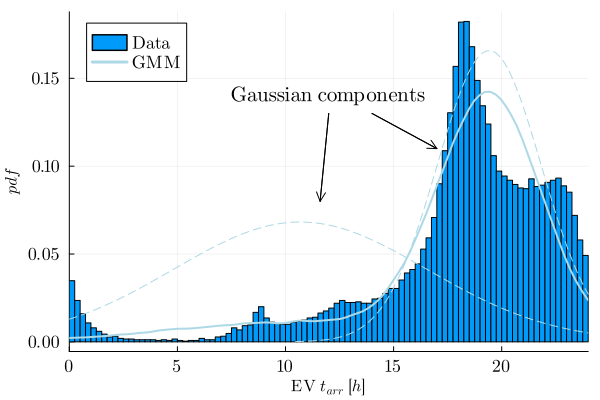

┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src\utils.jl:141
┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src\utils.jl:141
┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src\utils.jl:141
┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src\utils.jl:141
┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src\utils.jl:141
┌ Warning: Indices Base.OneTo(1) of attribute `linestyle` does not match data indices 1:119.
└ @ Plots C:\Users\dslaifstein\.julia\packages\Plots\rz1WP\src

In [44]:
plot(h, label=L"\textrm{Data}")
plot!(gmm, func=pdf,linestyles=[:dash], linecolor=:lightblue, label="", size=(600,400))
density!(rand(gmm, 100_000), linecolor=:lightblue, linewidth=2, xlabel = L"\textrm{EV}\ t_{arr}\ [h]", label = L"\textrm{GMM}",
        ylabel=L"pdf",xformatter=:latex, yformatter=:latex, xtickfontsize=12, ytickfontsize=12, legendfontsize=12)
xlims!((0, 24));
# Add arrow annotation
quiver!([12], [0.13], quiver=([-0.4], [-0.05]), color=:black)
quiver!([14], [0.13], quiver=([3], [-0.02]), color=:black)
annotate!([12], [0.14],L"\textrm{Gaussian\ components}")


Now that we have the model we can save it in a `.dat` file to be used by other scripts.

In [9]:
using Serialization
# Serialize the mixture model
open("gmmElaadFit.dat", "w") do f
    serialize(f, gmm)
end

In [24]:
using Serialization
# Deserialize the mixture model
open("gmmElaadFit.dat", "r") do f
    global gmm = deserialize(f)
end

MixtureModel{Normal{Float64}}(K = 2)
components[1] (prior = 0.8377): Normal{Float64}(μ=19.411568953330892, σ=2.4177007459259316)
components[2] (prior = 0.1623): Normal{Float64}(μ=10.624517677222592, σ=5.853601995408708)


In [25]:
gmm

MixtureModel{Normal{Float64}}(K = 2)
components[1] (prior = 0.8377): Normal{Float64}(μ=19.411568953330892, σ=2.4177007459259316)
components[2] (prior = 0.1623): Normal{Float64}(μ=10.624517677222592, σ=5.853601995408708)


# 2. Connection times

In [28]:
## Load Input Data
# Load the data from the EV Profile Tool
# density function of the arrival times
conn_times_df = CSV.read("CIRCE EV Profile Tool/Elaad Data/Data downloaded/distribution-of-connecti.csv", DataFrame);
conn_times_df


Row,Percentage of charging events,private,public,workplace
,Int64,Float64,Float64,Float64
1,0,72.0,72.0,72.0
2,1,56.5,44.9,46.4
3,2,43.0,38.8,25.7
4,3,38.8,29.1,20.1
5,4,35.4,23.7,16.6
6,5,29.3,21.7,13.2
7,6,25.1,20.4,11.2
8,7,23.4,19.4,10.6
9,8,22.2,18.5,10.2


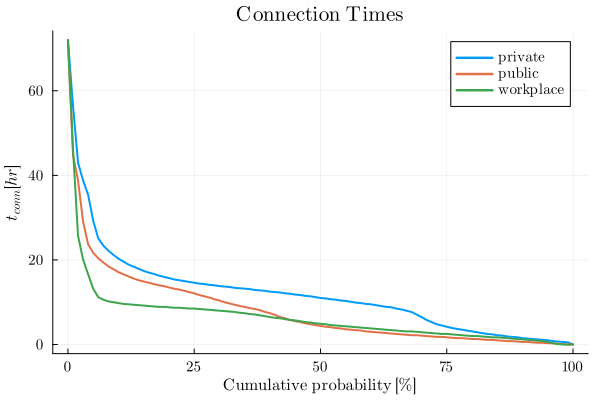

In [40]:
gr(display_type=:inline)
plot(conn_times_df[:, 1], conn_times_df[:, 2], label=L"\textrm{private}", linewidth=2, 
        ylabel=L"t_{conn} [hr]", xlabel=L"\textrm{Cumulative\ probability\ [\%]}",
        legend=:topright, title=L"\textrm{Connection\ Times}")
plot!(conn_times_df[:, 1], conn_times_df[:, 3], label=L"\textrm{public}", linewidth=2)
plot!(conn_times_df[:, 1], conn_times_df[:, 4], label=L"\textrm{workplace}", linewidth=2,
        xformatter=:latex, yformatter=:latex, xtickfontsize=10, ytickfontsize=10, legendfontsize=10)

In [45]:
tcon_cdf=ecdf(conn_times_df[:, 2], tail=:right);
plot(tcon_cdf, label=L"\textrm{private}", linewidth=2, 
        ylabel=L"t_{conn} [hr]", xlabel=L"\textrm{Cumulative\ probability\ [\%]}",
        legend=:topright, title=L"\textrm{Connection\ Times}")

MethodError: MethodError: no method matching ecdf(::Vector{Float64}; tail=:right)
Closest candidates are:
  ecdf(::AbstractVector{T} where T<:Real; weights) at C:\Users\dslaifstein\.julia\packages\StatsBase\XgjIN\src\empirical.jl:56 got unsupported keyword argument "tail"

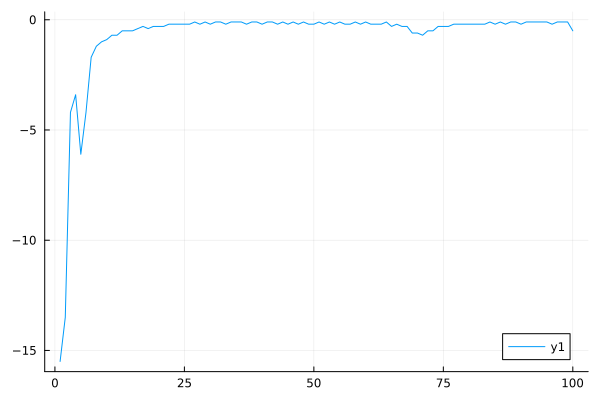

In [42]:
plot(diff(conn_times_df[:, 2] ))